In [1]:
!pip install numpy pandas matplotlib seaborn

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('/content/Raw_data(in).csv')
df.shape


(7043, 21)

In [7]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [10]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [11]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [12]:
df['Churn'] = df['Churn'].map({
    'Yes': 1,
    'No': 0
})

Visualization


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

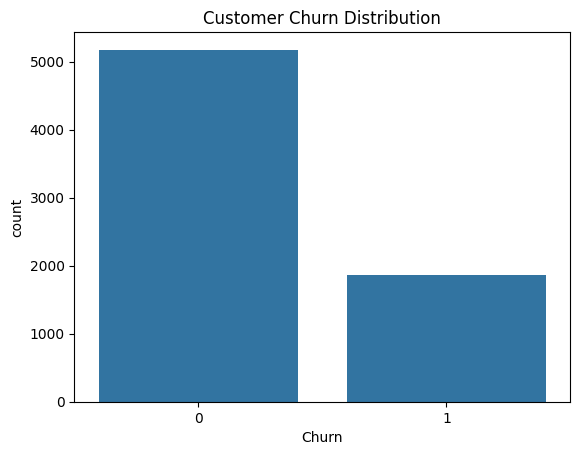

In [14]:
sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")
plt.show()

<Axes: xlabel='Contract', ylabel='count'>

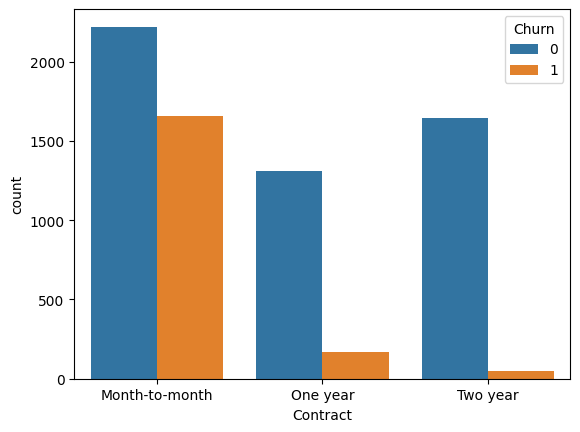

In [15]:
sns.countplot(
    x='Contract',
    hue='Churn',
    data=df
)

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

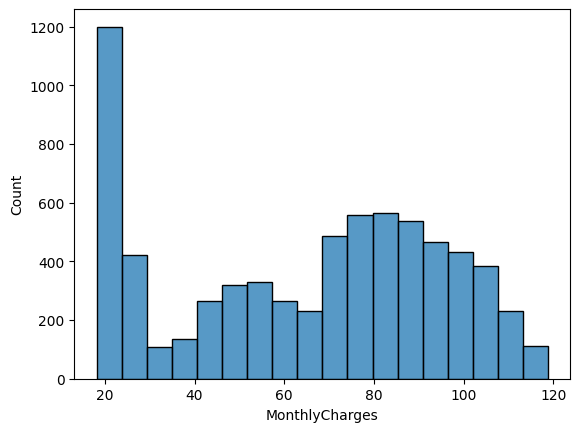

In [16]:
sns.histplot(df['MonthlyCharges'])

<Axes: xlabel='Churn', ylabel='tenure'>

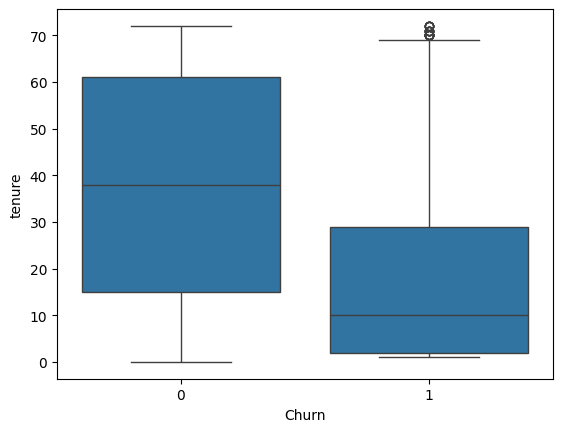

In [17]:
sns.boxplot(x='Churn', y='tenure', data=df)

Model Building

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [19]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

model = LogisticRegression(max_iter=1000) # Increased max_iter to ensure convergence

# Identify rows with NaN values in X_train
nan_rows_train = X_train.isnull().any(axis=1)

# Drop rows with NaN values from X_train and corresponding y_train
X_train_cleaned = X_train[~nan_rows_train]
y_train_cleaned = y_train[~nan_rows_train]

# Identify rows with NaN values in X_test
nan_rows_test = X_test.isnull().any(axis=1)

# Drop rows with NaN values from X_test and corresponding y_test
X_test_cleaned = X_test[~nan_rows_test]
y_test_cleaned = y_test[~nan_rows_test]

# Initialize and fit StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_cleaned)
X_test_scaled = scaler.transform(X_test_cleaned) # Transform X_test_cleaned using the same scaler

model.fit(X_train_scaled, y_train_cleaned)

LogisticRegression(max_iter=1000)

In [28]:
y_pred = model.predict(X_test_scaled)

In [30]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test_cleaned, y_pred)

print(accuracy)

0.8146306818181818


In [32]:
from sklearn.metrics import classification_report

print(classification_report(y_test_cleaned, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.90      0.88      1035
           1       0.68      0.57      0.62       373

    accuracy                           0.81      1408
   macro avg       0.77      0.74      0.75      1408
weighted avg       0.81      0.81      0.81      1408



<Axes: >

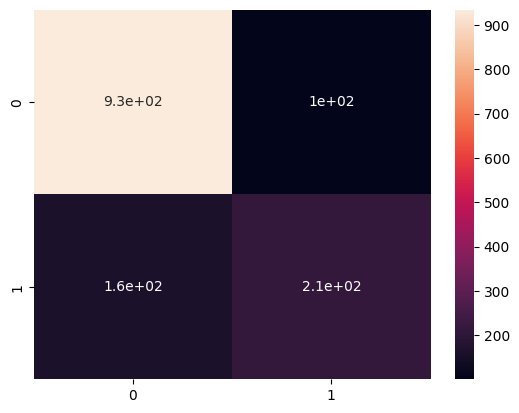

In [33]:
from sklearn.metrics import confusion_matrix

sns.heatmap(
    confusion_matrix(y_test_cleaned, y_pred),
    annot=True
)

In [34]:
from google.colab import files

df.to_csv('cleaned_churn.csv', index=False)
files.download('cleaned_churn.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>